# Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
dataset_url = "https://raw.githubusercontent.com/nmart1nezl/DataMiningProject/refs/heads/main/datasets/dataset_cleaned.csv"
df = pd.read_csv(dataset_url)
df.head()

,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,selfMade,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,associated_companies,number_of_companies
0,211000,Fashion & Retail,Bernard Arnault & family,74.080767,France,Paris,Retail and Consumer Goods,Consumer Discretionary,France,False,...,1.1,2.715518e+12,65.6,102.5,82.5,24.2,60.7,67059887.0,"LVMH (Louis Vuitton, Dior, Givenchy, Tiffany &...",75
1,180000,Automotive,Elon Musk,51.767283,United States,Austin,Technology,Consumer Discretionary,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Tesla, SpaceX, X (Twitter), Starlink, The Bori...",7
2,114000,Technology,Jeff Bezos,59.225188,United States,Medina,Technology,Technology & Telecommunications,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Amazon, Blue Origin, The Washington Post, Bezo...",100
3,107000,Technology,Larry Ellison,78.628337,United States,Lanai,Technology,Technology & Telecommunications,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Oracle, Tesla (stake), NetSuite, Sensei Ag, Pa...",5
4,106000,Finance & Investments,Warren Buffett,92.594114,United States,Omaha,Finance and Investments,Financials & Investments,United States,True,...,7.5,2.142770e+13,88.2,101.8,78.5,9.6,36.6,328239523.0,"Berkshire Hathaway (GEICO, Duracell, Dairy Que...",60


In [3]:
df.columns

Index(['finalWorth', 'category', 'personName', 'age', 'country', 'city',
       'source', 'industries', 'countryOfCitizenship', 'selfMade', 'status',
       'gender', 'birthDate', 'title', 'date', 'birthYear', 'cpi_country',
       'cpi_change_country', 'gdp_country',
       'gross_tertiary_education_enrollment',
       'gross_primary_education_enrollment_country', 'life_expectancy_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'population_country', 'associated_companies', 'number_of_companies'],
      dtype='object')

In [4]:
df.describe()

,finalWorth,age,birthYear,cpi_country,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,number_of_companies
count,2638.000000,2638.000000,2562.000000,2638.000000,2638.000000,2.638000e+03,2638.000000,2638.000000,2638.000000,2638.000000,2638.000000,2.638000e+03,2638.000000
mean,4626.307809,65.647529,1957.185012,127.091069,4.252729,1.187398e+13,67.148180,102.814670,78.158340,12.413685,43.848560,4.963488e+08,1.709629
std,9837.543000,13.080000,13.285180,25.737493,3.529792,9.512768e+12,20.696368,4.574701,3.629994,5.266169,11.764846,5.406691e+08,3.219182
min,1000.000000,18.910335,1921.000000,99.550000,-1.900000,3.154058e+09,4.000000,84.700000,54.300000,0.100000,9.900000,3.801900e+04,1.000000
25%,1500.000000,56.946612,1948.000000,117.240000,1.700000,1.736426e+12,50.600000,100.200000,77.000000,9.600000,36.600000,6.705989e+07,1.000000
50%,2300.000000,65.718001,1957.000000,117.240000,2.900000,1.991000e+13,66.300000,101.800000,78.500000,9.600000,41.800000,3.282395e+08,1.000000
75%,4200.000000,74.835044,1966.000000,125.080000,7.500000,2.142770e+13,88.200000,102.600000,80.900000,12.800000,59.100000,1.366418e+09,2.000000
max,211000.000000,101.560575,2004.000000,288.570000,53.500000,2.142770e+13,136.600000,142.100000,84.200000,37.200000,106.300000,1.397715e+09,100.000000


# Transform dataset to use on the classification problem

### New Target: `selfMade`

Now, let's focus on the `selfMade` column as our new target variable. This column indicates whether a person is self-made (True) or inherited their wealth (False).

In [5]:
print("Distribution of 'selfMade' (True/False):")
display(df['selfMade'].value_counts())

Distribution of 'selfMade' (True/False):


,count
selfMade,
True,1811
False,827


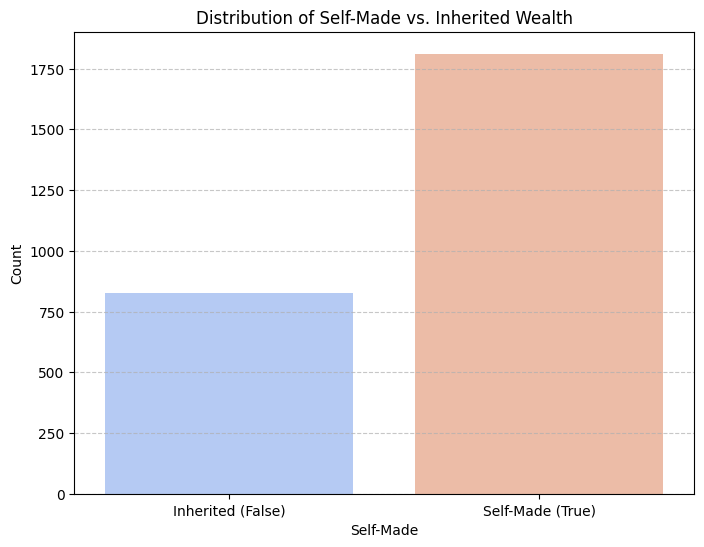

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='selfMade', hue='selfMade', palette='coolwarm', legend=False)
plt.title('Distribution of Self-Made vs. Inherited Wealth')
plt.xlabel('Self-Made')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Inherited (False)', 'Self-Made (True)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Drop unnecesary columns

In [ ]:
# List of columns to drop
columns_to_drop = ['personName', 'city', 'source', 'associated_companies', 'country', 'date', 'birthDate','birthYear','status']

# Drop the specified columns from the DataFrame
df = df.drop(columns=columns_to_drop)

print("Specified columns removed. DataFrame columns now are:")
display(df.columns)

Specified columns removed. DataFrame columns now are:


Index(['category', 'age', 'industries', 'countryOfCitizenship', 'selfMade',
       'gender', 'title', 'cpi_country', 'cpi_change_country', 'gdp_country',
       'gross_tertiary_education_enrollment',
       'gross_primary_education_enrollment_country', 'life_expectancy_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'population_country', 'number_of_companies', 'finalWorth_category'],
      dtype='object')

### Title

In [ ]:
df['title'].unique()


array(['Chairman & CEO', 'CEO, Founder & Engineer',
       'Executive Chair & Founder', 'Chairman, CTO & Cofounder',
       'Cofounder & Co-chair', 'Founder & Owner',
       'Honorary Chairman & Founder', 'Chairman & Managing Director',
       'Owner', 'Vice Chair & President', 'Cofounder & Board Member',
       'Founder & Former Chairman', 'Founder & Chairman',
       'Founder, Chairman & CEO', 'Chairman & Co-CEO',
       'Board Member & Owner', 'Former Chairman', 'Chairman',
       'Chairman & Founder', 'Cofounder & Chairman Emeritus', 'Founder',
       'Founder & Entrepreneur', 'Principal Shareholder & Investor',
       'Executive Chairman', 'Senior Advisor & Former Chairman',
       'Chairman and CEO', 'Founder & CEO',
       'Founder & Entrepreneur & Music',
       'Founder & Entrepreneur & Trading', 'CEO & Internet',
       'Founder & Entrepreneur & Steel', 'CEO', 'CEO & President',
       'Chairman Emeritus', 'Founder & Entrepreneur & Oil',
       'Founder & Co-Chief Investment 

In [ ]:
df['is_founder'] = df['title'].str.contains('Founder', case=False, na=False).astype(int)

df['is_ceo'] = df['title'].str.contains('CEO', case=False, na=False).astype(int)

df['is_chairman'] = df['title'].str.contains('Chairman', case=False, na=False).astype(int)

df['is_investor'] = df['title'].str.contains('Investor', case=False, na=False).astype(int)

df['is_entrepreneur'] = df['title'].str.contains('Entrepreneur', case=False, na=False).astype(int)

In [ ]:
df = df.drop(columns=['title'])

print("Specified columns removed. DataFrame columns now are:")
display(df.columns)

Specified columns removed. DataFrame columns now are:


Index(['category', 'age', 'industries', 'countryOfCitizenship', 'selfMade',
       'gender', 'cpi_country', 'cpi_change_country', 'gdp_country',
       'gross_tertiary_education_enrollment',
       'gross_primary_education_enrollment_country', 'life_expectancy_country',
       'tax_revenue_country_country', 'total_tax_rate_country',
       'population_country', 'number_of_companies', 'finalWorth_category',
       'is_founder', 'is_ceo', 'is_chairman', 'is_investor',
       'is_entrepreneur'],
      dtype='object')

In [ ]:
df[['is_ceo','is_founder','is_chairman','is_investor','is_entrepreneur']]

,is_ceo,is_founder,is_chairman,is_investor,is_entrepreneur
0,1,0,1,0,0
1,1,1,0,0,0
2,0,1,0,0,0
3,0,1,1,0,0
4,1,0,1,0,0
...,...,...,...,...,...
2633,0,1,0,0,1
2634,0,0,0,1,0
2635,0,1,0,0,1
2636,0,1,0,0,1


## tranform to log variables + Scale

We need to exclude with negative variables

In [ ]:
candidate_log_cols = ['cpi_country', 'gdp_country',
                      'tax_revenue_country_country', 'total_tax_rate_country',
                      'population_country']

In [ ]:
for col in candidate_log_cols:
    print(col, df[col].min())

cpi_country 99.55
gdp_country 3154057987.0
tax_revenue_country_country 0.1
total_tax_rate_country 9.9
population_country 38019.0


Let's visualize the distribution of the variables we intend to normalize to check for skewness.

Let's calculate the skewness for the numerical variables to determine if a logarithmic transformation is needed. A skewness value between -1 and 1 generally suggests a reasonably symmetric distribution.

In [ ]:
skewness_values = df[candidate_log_cols].skew()
print("Skewness of numerical variables:")
display(skewness_values)

Skewness of numerical variables:


,0
cpi_country,2.685096
gdp_country,-0.146317
tax_revenue_country_country,1.692095
total_tax_rate_country,0.244956
population_country,0.944081


Based on the skewness values, we will apply a logarithmic transformation (`np.log1p`) to the columns where the absolute skewness is greater than 1. This helps in reducing the skewness and making the distribution more symmetrical.

In [ ]:
import numpy as np

columns_to_log_transform = []
for col, skew in skewness_values.items():
    if abs(skew) > 1:
        columns_to_log_transform.append(col)

print(f"Applying log1p transformation to columns: {columns_to_log_transform}")

columns_to_drop_original = []
for col in columns_to_log_transform:
    # Using log1p to handle potential zero values safely (log(1+x))
    df[col + '_log'] = np.log1p(df[col])
    columns_to_drop_original.append(col)

# Drop the original columns that were transformed
df = df.drop(columns=columns_to_drop_original)

print("Original columns dropped. New columns created with '_log' suffix.")
print("Skewness after transformation for affected columns:")
display(df[[col + '_log' for col in columns_to_log_transform]].skew())

print("Updated DataFrame columns:")
display(df.columns)

Applying log1p transformation to columns: ['cpi_country', 'tax_revenue_country_country']
Original columns dropped. New columns created with '_log' suffix.
Skewness after transformation for affected columns:


,0
cpi_country_log,2.068415
tax_revenue_country_country_log,-1.004926


Updated DataFrame columns:


Index(['category', 'age', 'industries', 'countryOfCitizenship', 'selfMade',
       'gender', 'cpi_change_country', 'gdp_country',
       'gross_tertiary_education_enrollment',
       'gross_primary_education_enrollment_country', 'life_expectancy_country',
       'total_tax_rate_country', 'population_country', 'number_of_companies',
       'finalWorth_category', 'is_founder', 'is_ceo', 'is_chairman',
       'is_investor', 'is_entrepreneur', 'cpi_country_log',
       'tax_revenue_country_country_log'],
      dtype='object')

### Distribution of Original Variables (Before Log Transformation)

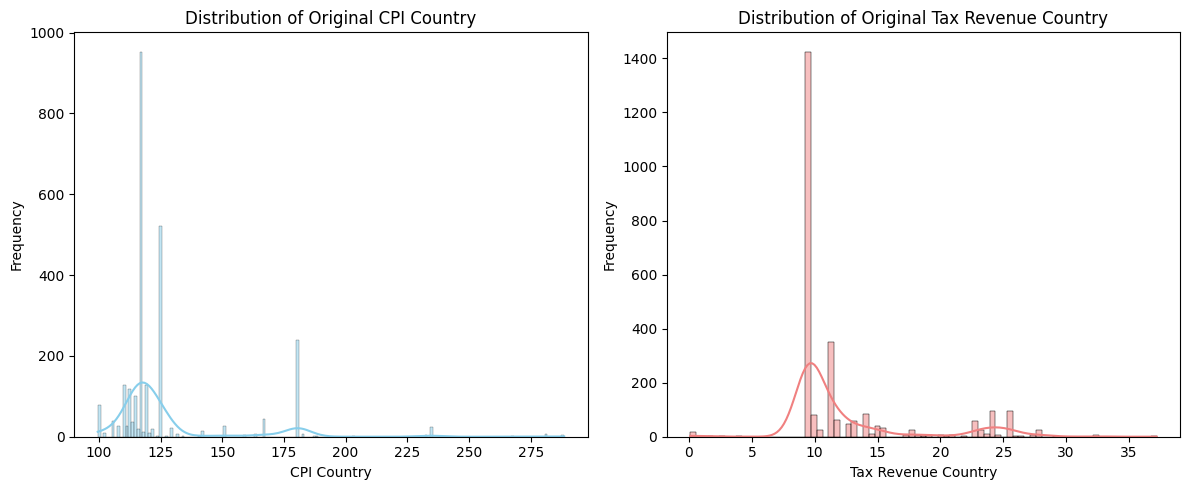

In [14]:
# Reload the original dataset into a new DataFrame to plot the untransformed variables
df_original = pd.read_csv(dataset_url)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_original['cpi_country'], kde=True, color='skyblue')
plt.title('Distribution of Original CPI Country')
plt.xlabel('CPI Country')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(df_original['tax_revenue_country_country'], kde=True, color='lightcoral')
plt.title('Distribution of Original Tax Revenue Country')
plt.xlabel('Tax Revenue Country')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
df.describe()

,age,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,total_tax_rate_country,population_country,number_of_companies,is_founder,is_ceo,is_chairman,is_investor,is_entrepreneur,cpi_country_log,tax_revenue_country_country_log
count,2638.000000,2638.000000,2.638000e+03,2638.000000,2638.000000,2638.000000,2638.000000,2.638000e+03,2638.000000,2638.000000,2638.000000,2638.000000,2638.000000,2638.000000,2638.000000,2638.000000
mean,65.647529,4.252729,1.187398e+13,67.148180,102.814670,78.158340,43.848560,4.963488e+08,1.709629,0.659591,0.034875,0.041319,0.335861,0.582259,4.837054,2.530868
std,13.080000,3.529792,9.512768e+12,20.696368,4.574701,3.629994,11.764846,5.406691e+08,3.219182,0.473937,0.183498,0.199065,0.472380,0.493280,0.167002,0.367604
min,18.910335,-1.900000,3.154058e+09,4.000000,84.700000,54.300000,9.900000,3.801900e+04,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.610655,0.095310
25%,56.946612,1.700000,1.736426e+12,50.600000,100.200000,77.000000,36.600000,6.705989e+07,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.772716,2.360854
50%,65.718001,2.900000,1.991000e+13,66.300000,101.800000,78.500000,41.800000,3.282395e+08,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4.772716,2.360854
75%,74.835044,7.500000,2.142770e+13,88.200000,102.600000,80.900000,59.100000,1.366418e+09,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,4.836917,2.624669
max,101.560575,53.500000,2.142770e+13,136.600000,142.100000,84.200000,106.300000,1.397715e+09,100.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.668397,3.642836


In [ ]:
df.to_csv("./classifiers_dataset.csv")